In [1]:
import numpy as np
import neuromaps.datasets
import torch
from einops import rearrange
from matplotlib import pyplot as plt
from PIL import Image

import yaspy

import flat_mae.transforms as flat_transforms
import flat_mae.nisc as nisc

In [2]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad

In [3]:
input_spaces = ["schaefer400", "flat", "mni_cortex"]

grads = {}
for space in input_spaces:
    grads[space] = np.load(f"results/pca_{space}.npz")["components"]

2026-03-02 15:08:45.803 (   5.834s) [    7828D414D740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


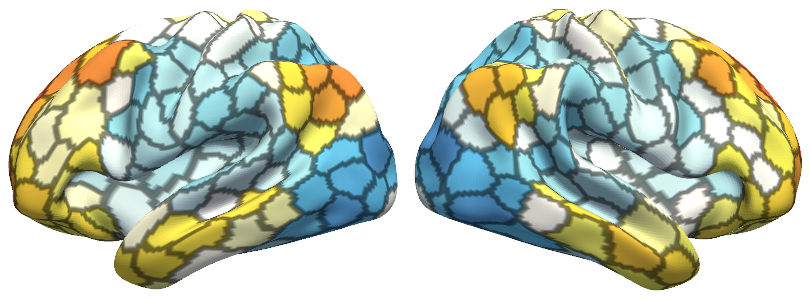

In [4]:
parc_path = nisc.fetch_schaefer(400, space="fslr64k")
parc = nisc.read_cifti_surf_data(parc_path).squeeze(0).astype(np.int64)

bold = -grads["schaefer400"][0]
bold = bold / bold.std()
bold_ = np.zeros(parc.size, dtype=bold.dtype)
bold_[parc > 0] = bold[parc[parc > 0] - 1]
bold = bold_
bold_l, bold_r = np.split(bold, 2)
parc_l, parc_r = np.split(parc, 2)

surfaces = neuromaps.datasets.fetch_fslr()
surf_lh_path, surf_rh_path = surfaces["inflated"]

plotter_l = yaspy.Plotter(surf_lh_path, hemi="lh", width=384)
plotter_l.overlay(
    np.where(bold_l != 0, bold_l, np.nan),
    cmap=nisc.FC_CMAP,
    vmin=-3,
    vmax=3,
)
plotter_l.border(parc_l, alpha=0.5)

for light in plotter_l._plotter.renderer.lights:
    light.intensity *= 1.3

img_l = plotter_l.screenshot()

plotter_r = yaspy.Plotter(surf_rh_path, hemi="rh", width=384)
plotter_r.overlay(
    np.where(bold_r != 0, bold_r, np.nan),
    cmap=nisc.FC_CMAP,
    vmin=-3,
    vmax=3,
)
plotter_r.border(parc_r, alpha=0.5)

for light in plotter_r._plotter.renderer.lights:
    light.intensity *= 1.3
img_r = plotter_r.screenshot()

img = yaspy.montage([[img_l, img_r]], pad=8)
img.save("results/pca_schaefer400.png")
img

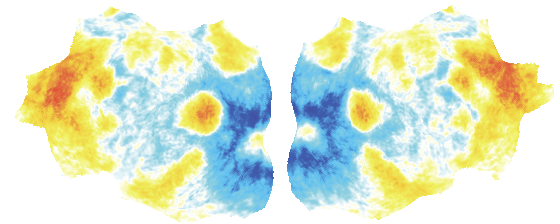

In [5]:
bold = grads["flat"][0]
bold = bold / bold.std()

unmask = flat_transforms.get_unmask("flat")
bold_ = np.zeros(unmask.mask.shape, dtype=bold.dtype)
bold_[unmask.mask.numpy()] = bold
bold = bold_

mask = bold != 0
cmap = nisc.FC_CMAP
cmap.set_bad("none")
vmax = 3
bold = np.where(mask, bold, np.nan)
img = cmap(np.clip((bold + vmax) / (2 * vmax), 0, 1))
img = (255 * img).astype(np.uint8)
img = Image.fromarray(img)
img.save("results/pca_flat.png")
img

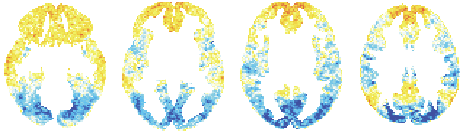

In [6]:
bold = grads["mni_cortex"][1]
bold = bold / bold.std()

unmask = flat_transforms.get_unmask("mni_cortex")
bold_ = np.zeros(unmask.mask.shape, dtype=bold.dtype)
bold_[unmask.mask.numpy()] = bold
bold = bold_

mask = bold != 0
zids, yids, xids = mask.nonzero()
ymin = yids.min() - 1
ymax = yids.max()
xmin = xids.min() - 1
xmax = xids.max()

nc = 4
f, axs = plt.subplots(1, nc)

start = 28
stride = 7

cmap = nisc.FC_CMAP
cmap.set_bad("none")

for ii, ax in enumerate(axs):
    plt.sca(ax)
    idx = start + ii * stride
    img = bold[idx, ymin:ymax, xmin:xmax]
    plt.imshow(
        np.where(img != 0, img, np.nan),
        cmap=cmap,
        vmin=-3,
        vmax=3,
        origin="lower",
        interpolation="none",
    )
    plt.axis("off")

plt.tight_layout()
f.savefig("results/pca_mni_cortex.png", transparent=True, dpi=300)

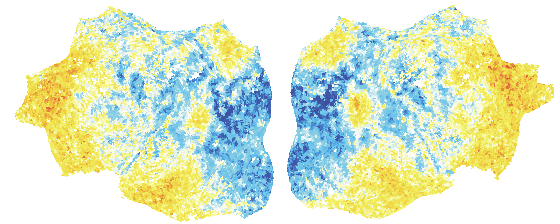

In [7]:
bold = grads["mni_cortex"][1]
bold = bold / bold.std()
bold = torch.from_numpy(bold)

unmask = flat_transforms.get_unmask("mni_cortex")
bold = unmask.transform(bold)
bold = unmask.to_flat(bold)

mask = bold != 0
cmap = nisc.FC_CMAP
cmap.set_bad("none")
vmax = 3
bold = np.where(mask, bold, np.nan)
img = cmap(np.clip((bold + vmax) / (2 * vmax), 0, 1))
img = (255 * img).astype(np.uint8)
img = Image.fromarray(img)
img

In [8]:
def plot_parcel_patches(
    bold: np.ndarray,
    nrow: int = 1,
    ncol: int = 6,
):
    """
    bold: array of parcel fmri values, shape (n_parcels,)

    plot a `nrow x ncol` grid of circle markers representing parcellated fmri values.
    rgb color values of each marker are color-mapped bold signal values. parcel indices
    selected by linear spaced indexing.
    """
    ec = "k"
    ms = 12
    cmap = nisc.FC_CMAP
    vmax = 3

    n_patches = nrow * ncol
    indices = np.linspace(0, len(bold) - 1, n_patches, dtype=int)
    patches = bold[indices]

    # Map values to RGBA colors
    normed = np.clip((patches + vmax) / (2 * vmax), 0, 1)
    colors = cmap(normed)

    fig, ax = plt.subplots(figsize=(ncol * 0.6, nrow * 0.6))

    for ii in range(n_patches):
        r = ii // ncol
        c = ii % ncol
        ax.plot(
            c,
            nrow - 1 - r,
            "o",
            color=colors[ii],
            markersize=ms,
            markeredgecolor=ec,
            markeredgewidth=1.0,
        )

    ax.set_xlim(-0.5, ncol - 0.5)
    ax.set_ylim(-0.5, nrow - 0.5)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    return fig

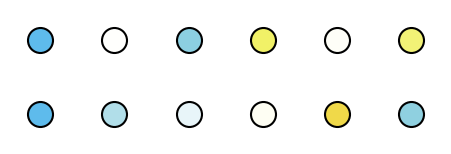

In [9]:
bold = -grads["schaefer400"][0]
bold = bold / bold.std()
f = plot_parcel_patches(bold, 2, 6)
f.savefig("results/patches_schaefer400.png", transparent=True, dpi=500)

In [10]:
def plot_flat_patches(
    bold: np.ndarray,
    nrow: int = 1,
    ncol: int = 6,
):
    """
    bold: array of parcel fmri values, shape (n_patches, patch_h, patch_w)

    plot a `nrow x ncol` grid of square patches representing the values of an fmri flat map.
    """
    ec = "k"
    cmap = nisc.FC_CMAP
    cmap.set_bad("gray")
    vmax = 3

    n_patches = nrow * ncol
    indices = np.linspace(0, len(bold) - 1, n_patches, dtype=int)
    patches = bold[indices]

    ph, pw = patches.shape[1], patches.shape[2]
    fig, axs = plt.subplots(nrow, ncol, figsize=(ncol * 0.6, nrow * 0.6))
    axs = axs.flatten()

    for ii, ax in enumerate(axs):
        patch = patches[ii]
        ax.imshow(
            np.where(patch != 0, patch, np.nan),
            cmap=cmap,
            vmin=-vmax,
            vmax=vmax,
            interpolation="none",
        )
        ax.set_xlim(-0.5, pw - 0.5)
        ax.set_ylim(-0.5, ph - 0.5)
        ax.set_aspect("equal")
        ax.axis("off")

        # Draw border around patch
        rect = plt.Rectangle(
            (-0.5, -0.5),
            pw,
            ph,
            linewidth=2.0,
            edgecolor=ec,
            facecolor="none",
        )
        ax.add_patch(rect)

    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    return fig

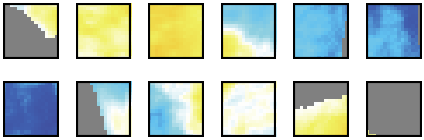

In [11]:
bold = grads["flat"][0]
bold = bold / bold.std()

unmask = flat_transforms.get_unmask("flat")
bold_ = np.zeros(unmask.mask.shape, dtype=bold.dtype)
bold_[unmask.mask.numpy()] = bold
bold = bold_

H, W = bold.shape
bold = rearrange(bold, "(h p) (w q) -> (h w) p q", p=16, q=16)
mask = (bold != 0).any(axis=(1, 2))
bold = bold[mask]

f = plot_flat_patches(bold, 2, 6)
f.savefig("results/patches_flat.png", transparent=True, dpi=500)

In [16]:
import pyvista as pv


def _render_volume_patch(patch, cmap, vmax, edge_color="k", bg_color="gray"):
    """Render a single 8x8x8 volume patch with PyVista, return RGBA screenshot."""
    d, h, w = patch.shape

    # Brain voxels mesh (colored by BOLD)
    grid = pv.ImageData(dimensions=(w + 1, h + 1, d + 1))
    grid.cell_data["values"] = patch.flatten(order="F")
    grid.cell_data["mask"] = (patch != 0).astype(np.float32).flatten(order="F")

    threshed = grid.threshold(value=0.5, scalars="mask", preference="cell")
    if threshed.n_cells == 0:
        return None

    # Color-map values to RGB
    normed = np.clip((threshed.cell_data["values"] + vmax) / (2 * vmax), 0, 1)
    colors = (cmap(normed)[:, :3] * 255).astype(np.uint8)
    threshed.cell_data["rgb"] = colors

    # Non-brain voxels mesh (gray fill)
    bg_threshed = grid.threshold(value=0.5, scalars="mask", preference="cell", invert=True)

    plotter = pv.Plotter(off_screen=True, window_size=(256, 256))

    # Add brain voxels without edges, flat lighting
    plotter.add_mesh(threshed, scalars="rgb", rgb=True, show_edges=False, lighting=False)

    # Add non-brain voxels as gray fill without edges, flat lighting
    if bg_threshed.n_cells > 0:
        plotter.add_mesh(bg_threshed, color=bg_color, show_edges=False, lighting=False)

    # Add wireframe outline of the full 8x8x8 bounding box
    outline = grid.outline()
    plotter.add_mesh(outline, color=edge_color, line_width=4.0)

    plotter.camera_position = "iso"
    plotter.camera.parallel_projection = True
    plotter.camera.zoom(1.0)
    img = plotter.screenshot(return_img=True, transparent_background=True)
    plotter.close()

    # Crop to non-transparent bounding box
    alpha = img[:, :, 3]
    rows = np.any(alpha > 0, axis=1)
    cols = np.any(alpha > 0, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    img = img[rmin : rmax + 1, cmin : cmax + 1]

    return img


def plot_volume_patches(
    bold: np.ndarray,
    nrow: int = 1,
    ncol: int = 6,
):
    """
    bold: array of parcel fmri values, shape (n_patches, patch_d, patch_h, patch_w)

    plot a `nrow x ncol` grid of cubes representing the values of an fmri cortical volume.
    """
    ec = "k"
    cmap = nisc.FC_CMAP
    cmap.set_bad("gray")
    vmax = 3

    n_patches = nrow * ncol
    indices = np.linspace(0, len(bold) - 1, n_patches, dtype=int)
    patches = bold[indices]

    # Render all patches
    screenshots = []
    for ii in range(n_patches):
        img = _render_volume_patch(patches[ii], cmap, vmax, edge_color=ec)
        screenshots.append(img)

    fig, axs = plt.subplots(nrow, ncol, figsize=(ncol * 0.6, nrow * 0.6))
    axs = np.atleast_2d(axs)

    for ii, ax in enumerate(axs.flat):
        if screenshots[ii] is not None:
            ax.imshow(screenshots[ii])
        ax.set_aspect("equal")
        ax.axis("off")

    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    return fig

(466, 8, 8, 8)


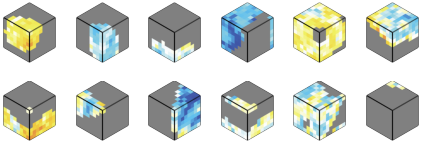

In [17]:
bold = grads["mni_cortex"][1]
bold = bold / bold.std()

unmask = flat_transforms.get_unmask("mni_cortex")
bold = unmask.transform(torch.from_numpy(bold)).numpy()
bold = bold.reshape(-1, 8, 8, 8)
print(bold.shape)

f = plot_volume_patches(bold, 2, 6)
f.savefig("results/patches_mni_cortex.png", transparent=True, dpi=500)